# `local_thickness_dt`
Computes local thickness by repeatedly thresholding a distance transform and redilating the result with a second distance transform. This is the default implementation used by `local_thickness`.

See the `local_thickness` notebook for a detailed walk-through of the shared concepts; this page focuses on the variant-specific arguments. The wrapper `ps.filters.local_thickness` dispatches to this function when its `method` argument selects this variant.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.local_thickness_dt)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], dt: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]] = None, sizes: int = 25, smooth: bool = True)>

## `im` and `sizes`
`im` is the boolean void mask. `sizes` is the number of erosion-dilation steps (int, the default 25 means logarithmically spaced bins between the maximum of the distance transform and 1) or an explicit array of radii to use.

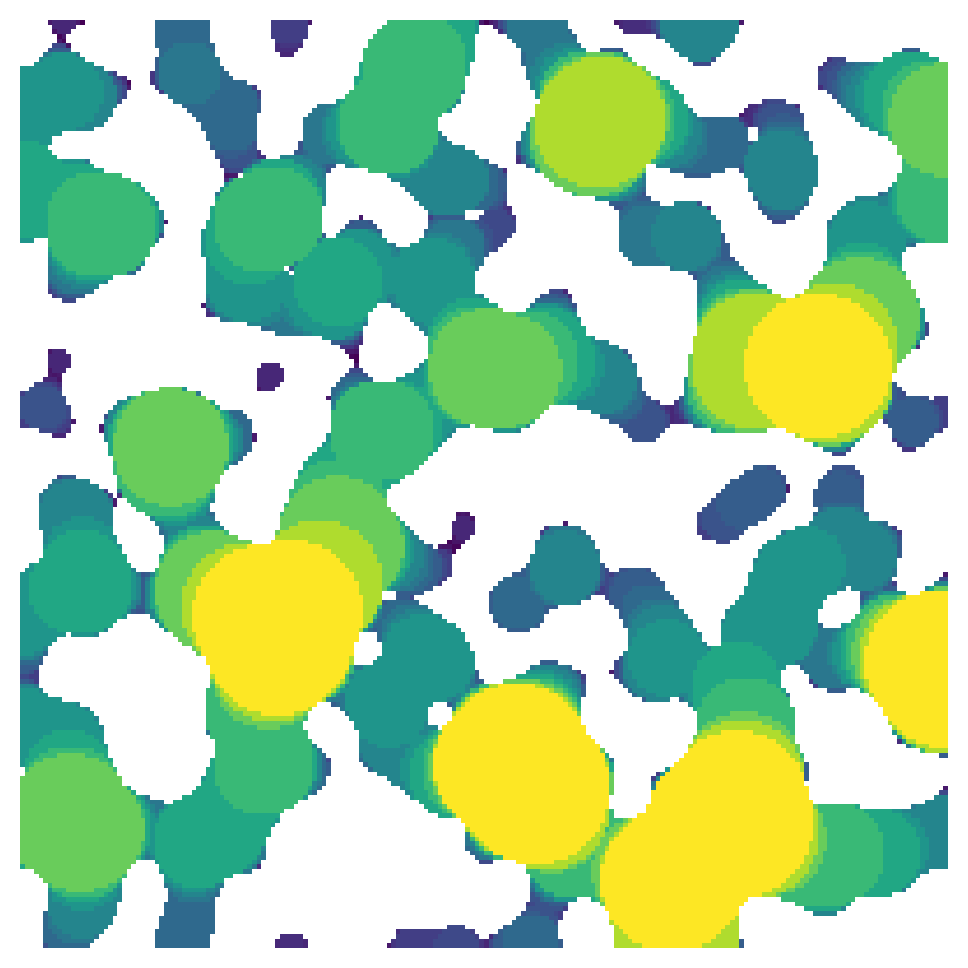

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
lt = ps.filters.local_thickness_dt(im=im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(lt / im, origin='lower', interpolation='none')
ax.axis(False);

## `dt`
If a distance transform is already available it can be passed in to skip recomputation.

In [4]:
from porespy.tools import get_edt

dt = get_edt()(im)
lt = ps.filters.local_thickness_dt(im=im, dt=dt, sizes=15)

## `smooth`
Same meaning as in `dilate` and `erode`: when `True` (default) protrusions are trimmed from the spheres used during the dilation step.

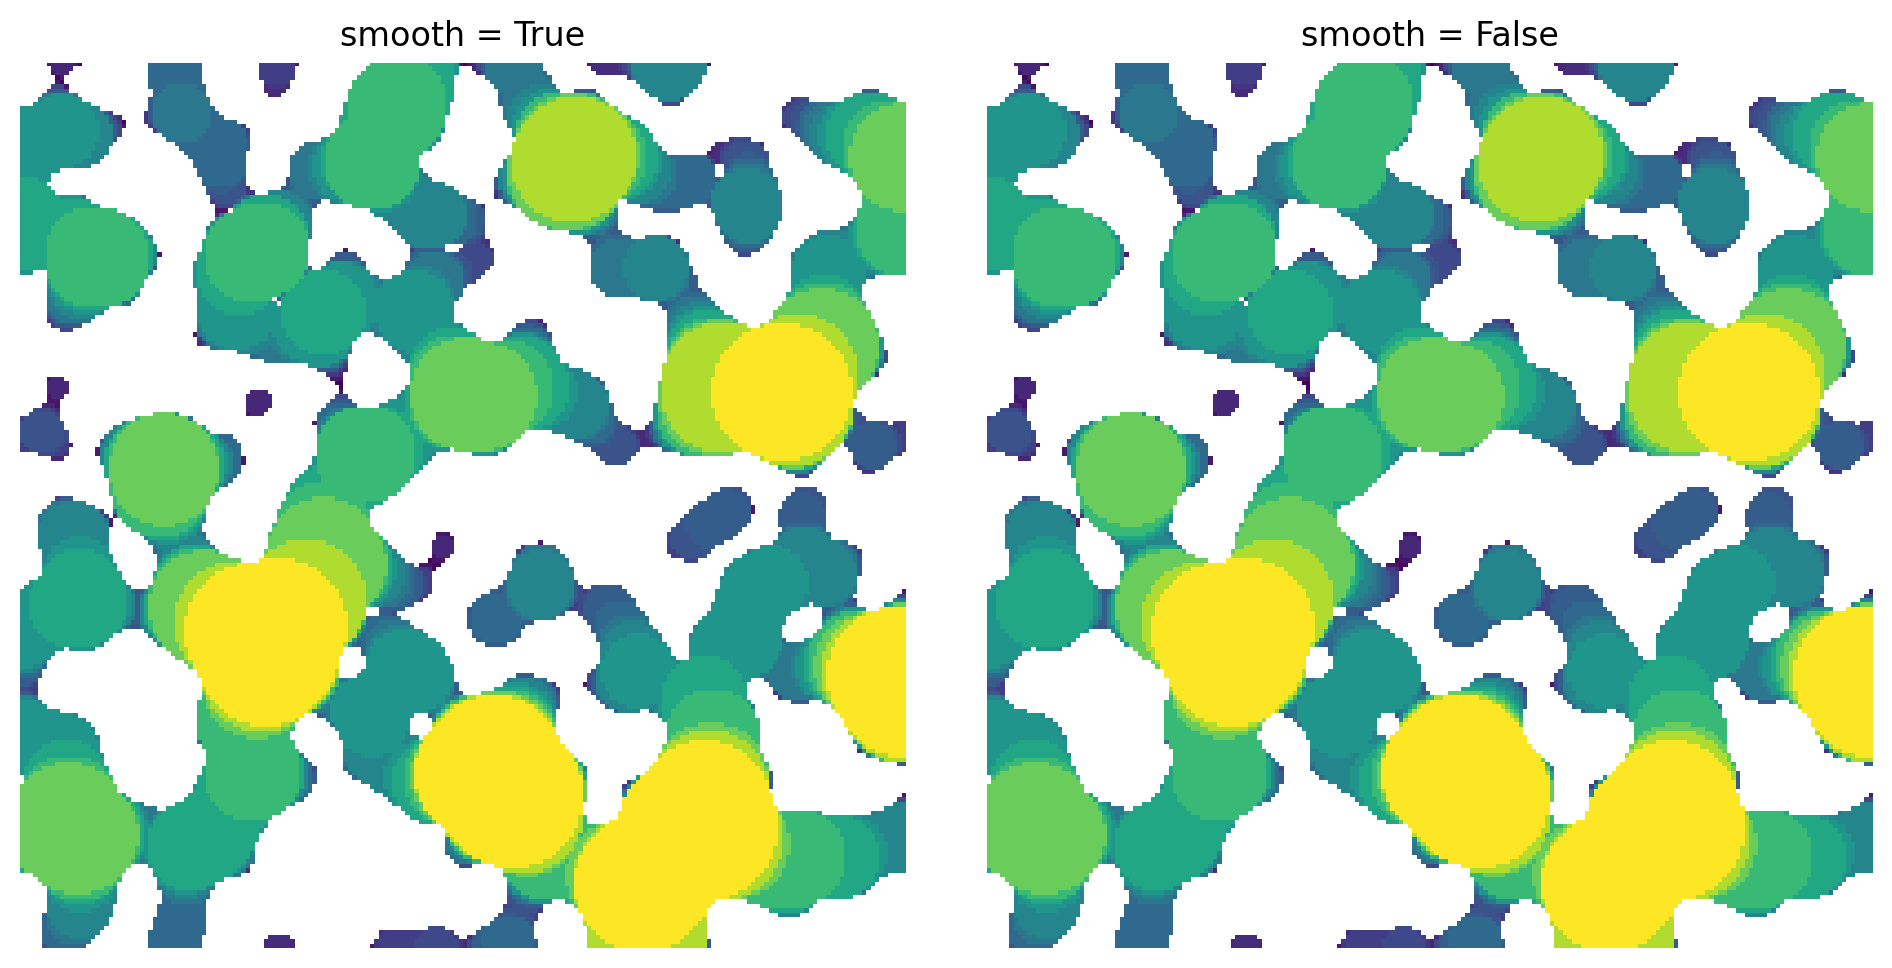

In [5]:
lt_smooth = ps.filters.local_thickness_dt(im=im, smooth=True)
lt_rough = ps.filters.local_thickness_dt(im=im, smooth=False)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(lt_smooth / im, origin='lower', interpolation='none')
ax[0].set_title('smooth = True')
ax[0].axis(False)
ax[1].imshow(lt_rough / im, origin='lower', interpolation='none')
ax[1].set_title('smooth = False')
ax[1].axis(False);